## Cell 1: Imports and Initial Setup

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F
from PIL import Image
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import cv2
import scipy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Cell 2: Dataset Path Configuration

In [2]:
dataset_root = './ShanghaiTech/'

part_b_train_path = os.path.join(dataset_root, 'part_B', 'train_data')
part_b_test_path = os.path.join(dataset_root, 'part_B', 'test_data')

## Cell 3: Ground Truth Density Map Generation

In [3]:
def create_density_map(image_shape, points):
    """
    Generates a density map from ground truth point annotations.
    
    Args:
        image_shape (tuple): The (height, width) of the image.
        points (np.ndarray): An array of shape (N, 2) with head coordinates.

    Returns:
        np.ndarray: The ground truth density map.
    """
    h, w = image_shape
    density_map = np.zeros((h, w), dtype=np.float32)
    num_points = len(points)

    if num_points == 0:
        return density_map

    leafsize = 2048
    tree = scipy.spatial.KDTree(points.copy(), leafsize=leafsize)
    distances, _ = tree.query(points, k=4)

    for i, pt in enumerate(points):
        pt2d = np.zeros_like(density_map, dtype=np.float32)
        x, y = int(min(w-1, pt[0])), int(min(h-1, pt[1]))
        
        if x < w and y < h:
            pt2d[y, x] = 1.
        
        if num_points > 1:
            sigma = (distances[i][1] + distances[i][2] + distances[i][3]) * 0.1
        else:
            sigma = np.average(np.array(image_shape))/2./2. 
         
        density_map += cv2.GaussianBlur(pt2d, (0, 0), sigma, borderType=cv2.BORDER_CONSTANT)
        
    return density_map

## Cell 4: Custom PyTorch Dataset Class

In [4]:
class ShanghaiTechDataset(Dataset):
    def __init__(self, root_path, transform=None, train=True, downsample_factor=4, target_size=None):
        self.root = root_path
        self.transform = transform
        self.downsample_factor = downsample_factor
        self.target_size = target_size
        
        self.image_paths = sorted([os.path.join(self.root, 'images', img) for img in os.listdir(os.path.join(self.root, 'images')) if img.endswith('.jpg')])
        self.gt_paths = sorted([os.path.join(self.root, 'ground-truth', gt) for gt in os.listdir(os.path.join(self.root, 'ground-truth')) if gt.endswith('.mat')])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        gt_path = self.gt_paths[idx]
        mat = scipy.io.loadmat(gt_path)
        points = mat['image_info'][0, 0][0, 0][0]
        
        original_w, original_h = image.size

        if self.target_size:
            image = image.resize(self.target_size, Image.BILINEAR)
            new_w, new_h = self.target_size
            scale_w = new_w / original_w
            scale_h = new_h / original_h
            points[:, 0] = points[:, 0] * scale_w
            points[:, 1] = points[:, 1] * scale_h

        current_h, current_w = image.size[::-1]
        density_map = create_density_map((current_h, current_w), points)
        
        ds_h, ds_w = current_h // self.downsample_factor, current_w // self.downsample_factor
        density_map = cv2.resize(density_map, (ds_w, ds_h), interpolation=cv2.INTER_AREA)
        density_map *= (self.downsample_factor ** 2)
        
        if self.transform:
            image = self.transform(image)
            
        density_map = torch.from_numpy(density_map).unsqueeze(0)
        
        return image, density_map

## Cell 5: The MCNN Model Architecture

In [5]:
class MCNN(nn.Module):
    def __init__(self):
        super(MCNN, self).__init__()
        self.column_L = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=9, padding=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.column_M = nn.Sequential(
            nn.Conv2d(3, 20, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(20, 40, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.column_S = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.merge_layer = nn.Sequential(
            nn.Conv2d(120, 1, kernel_size=1)
        )

    def forward(self, x):
        x_L = self.column_L(x)
        x_M = self.column_M(x)
        x_S = self.column_S(x)
        
        x_cat = torch.cat((x_L, x_M, x_S), 1)
        
        out = self.merge_layer(x_cat)
        
        return out

## Cell 6: Hyperparameters and Dataloader Setup

In [6]:
LEARNING_RATE = 1e-5
BATCH_SIZE = 2
EPOCHS = 50
DOWNSAMPLE_FACTOR = 4
MANAGEABLE_SIZE = (512, 384)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ShanghaiTechDataset(root_path=part_b_train_path, target_size=MANAGEABLE_SIZE, transform=transform, train=True, downsample_factor=DOWNSAMPLE_FACTOR)
test_dataset = ShanghaiTechDataset(root_path=part_b_test_path, target_size=MANAGEABLE_SIZE, transform=transform, train=False, downsample_factor=DOWNSAMPLE_FACTOR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

## Cell 7: Training and Validation Loop

In [ ]:
model = MCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_mae = float('inf')

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for i, (images, gt_maps) in enumerate(train_loader):
        images = images.to(device)
        gt_maps = gt_maps.to(device)

        pred_maps = model(images)
        loss = criterion(pred_maps, gt_maps)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {epoch_loss/len(train_loader):.4f}")

    model.eval()
    mae = 0
    with torch.no_grad():
        for images, gt_maps in test_loader:
            images = images.to(device)
            
            pred_maps = model(images)
            
            pred_count = pred_maps.sum().item()
            true_count = gt_maps.sum().item()
            
            mae += abs(pred_count - true_count)
            
    mae /= len(test_loader)
    print(f"Validation MAE: {mae:.2f}")

    if mae < best_mae:
        best_mae = mae
        torch.save(model.state_dict(), 'best_mcnn_model.pth')
        print(f"New best model saved with MAE: {best_mae:.2f}")

Epoch [1/2], Train Loss: 0.0106
Validation MAE: 175.91
New best model saved with MAE: 175.91
Epoch [2/2], Train Loss: 0.0099
Validation MAE: 106.16
New best model saved with MAE: 106.16


## Cell 8: Final Evaluation on Test Set

In [ ]:
model = MCNN().to(device)
model.load_state_dict(torch.load('best_mcnn_model.pth'))
model.eval()

final_mae = 0
final_mse = 0

with torch.no_grad():
    for images, gt_maps in test_loader:
        images = images.to(device)
        pred_maps = model(images)
        
        pred_count = pred_maps.sum().item()
        true_count = gt_maps.sum().item()
        
        final_mae += abs(pred_count - true_count)
        final_mse += (pred_count - true_count)**2

final_mae /= len(test_loader)
final_mse = (final_mse / len(test_loader))**0.5

print(f"Final Test MAE: {final_mae:.2f}")
print(f"Final Test MSE: {final_mse:.2f}")

Final Test MAE: 106.16
Final Test MSE: 149.86


## Cell 10: Define the U-Net Model for Crowd Counting

In [7]:
class DoubleConv(nn.Module):
    """(Convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class DownSample(nn.Module):
    """Downscaling with MaxPool then DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self, x):
        return self.maxpool_conv(x)

class UpSample(nn.Module):
    """Upscaling then DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels=1):
        super(UNet, self).__init__()
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = DownSample(64, 128)
        self.down2 = DownSample(128, 256)

        self.up3 = UpSample(256, 128)
        self.up4 = UpSample(128, 64)
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        original_h, original_w = x.shape[2], x.shape[3]
        pad_h = (4 - original_h % 4) % 4
        pad_w = (4 - original_w % 4) % 4
        x = F.pad(x, [0, pad_w, 0, pad_h])

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        
        x = self.up3(x3, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        
        logits = logits[:, :, :original_h, :original_w]
        return logits

print("U-Net model structure defined successfully for crowd counting.")

U-Net model structure defined successfully for crowd counting.


## Cell 11: Train the U-Net Model

In [ ]:
print("\n--- Starting Lightest U-Net Training ---")
unet_model = UNet(in_channels=3, out_channels=1).to(device)
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(unet_model.parameters(), lr=LEARNING_RATE)

best_mae_unet = float('inf')

for epoch in range(EPOCHS):
    unet_model.train()
    epoch_loss_unet = 0
    for i, (images, gt_maps) in enumerate(train_loader):
        images = images.to(device)
        gt_maps = gt_maps.to(device)
        
        pred_maps = unet_model(images)
        pred_maps_downsampled = F.interpolate(pred_maps, scale_factor=1/DOWNSAMPLE_FACTOR, mode='area')
        loss = criterion(pred_maps_downsampled, gt_maps)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss_unet += loss.item()
    
    print(f"Lightest U-Net Epoch [{epoch+1}/{EPOCHS}], Train Loss: {epoch_loss_unet/len(train_loader):.4f}")

    unet_model.eval()
    mae_unet = 0
    with torch.no_grad():
        for images, gt_maps in test_loader:
            images = images.to(device)
            gt_maps = gt_maps.to(device)
            pred_maps = unet_model(images)
            pred_maps_downsampled = F.interpolate(pred_maps, scale_factor=1/DOWNSAMPLE_FACTOR, mode='area')
            pred_count = pred_maps_downsampled.sum().item()
            true_count = gt_maps.sum().item()
            mae_unet += abs(pred_count - true_count)
            
    mae_unet /= len(test_loader)
    print(f"U-Net Validation MAE: {mae_unet:.2f}")

    if mae_unet < best_mae_unet:
        best_mae_unet = mae_unet
        torch.save(unet_model.state_dict(), 'best_unet_model.pth')
        print(f"New best U-Net model saved with MAE: {best_mae_unet:.2f}")


--- Starting Lightest U-Net Training ---


Lightest U-Net Epoch [1/2], Train Loss: 0.0146
U-Net Validation MAE: 241.62
New best U-Net model saved with MAE: 241.62
Lightest U-Net Epoch [2/2], Train Loss: 0.0107
U-Net Validation MAE: 101.64
New best U-Net model saved with MAE: 101.64


## Cell 12: Final Evaluation on the U-Net Model

In [ ]:
print("\n--- Final Evaluation on U-Net ---")
unet_model = UNet(in_channels=3, out_channels=1).to(device)
unet_model.load_state_dict(torch.load('best_unet_model.pth'))
unet_model.eval()

final_mae_unet = 0
final_mse_unet = 0

with torch.no_grad():
    for images, gt_maps in test_loader:
        images = images.to(device)
        gt_maps_downsampled = F.interpolate(gt_maps, scale_factor=1/DOWNSAMPLE_FACTOR, mode='area')

        pred_maps = unet_model(images)
        
        pred_count = pred_maps.sum().item()
        true_count = gt_maps_downsampled.sum().item()
        
        final_mae_unet += abs(pred_count - true_count)
        final_mse_unet += (pred_count - true_count)**2

final_mae_unet /= len(test_loader)
final_mse_unet = (final_mse_unet / len(test_loader))**0.5

print(f"U-Net Final Test MAE: {final_mae_unet:.2f}")
print(f"U-Net Final Test MSE: {final_mse_unet:.2f}")


--- Final Evaluation on U-Net ---
U-Net Final Test MAE: 3927.50
U-Net Final Test MSE: 4101.24


## Cell 13: Visualize U-Net Results

Saving visualization images to the 'output_visualizations/' directory.


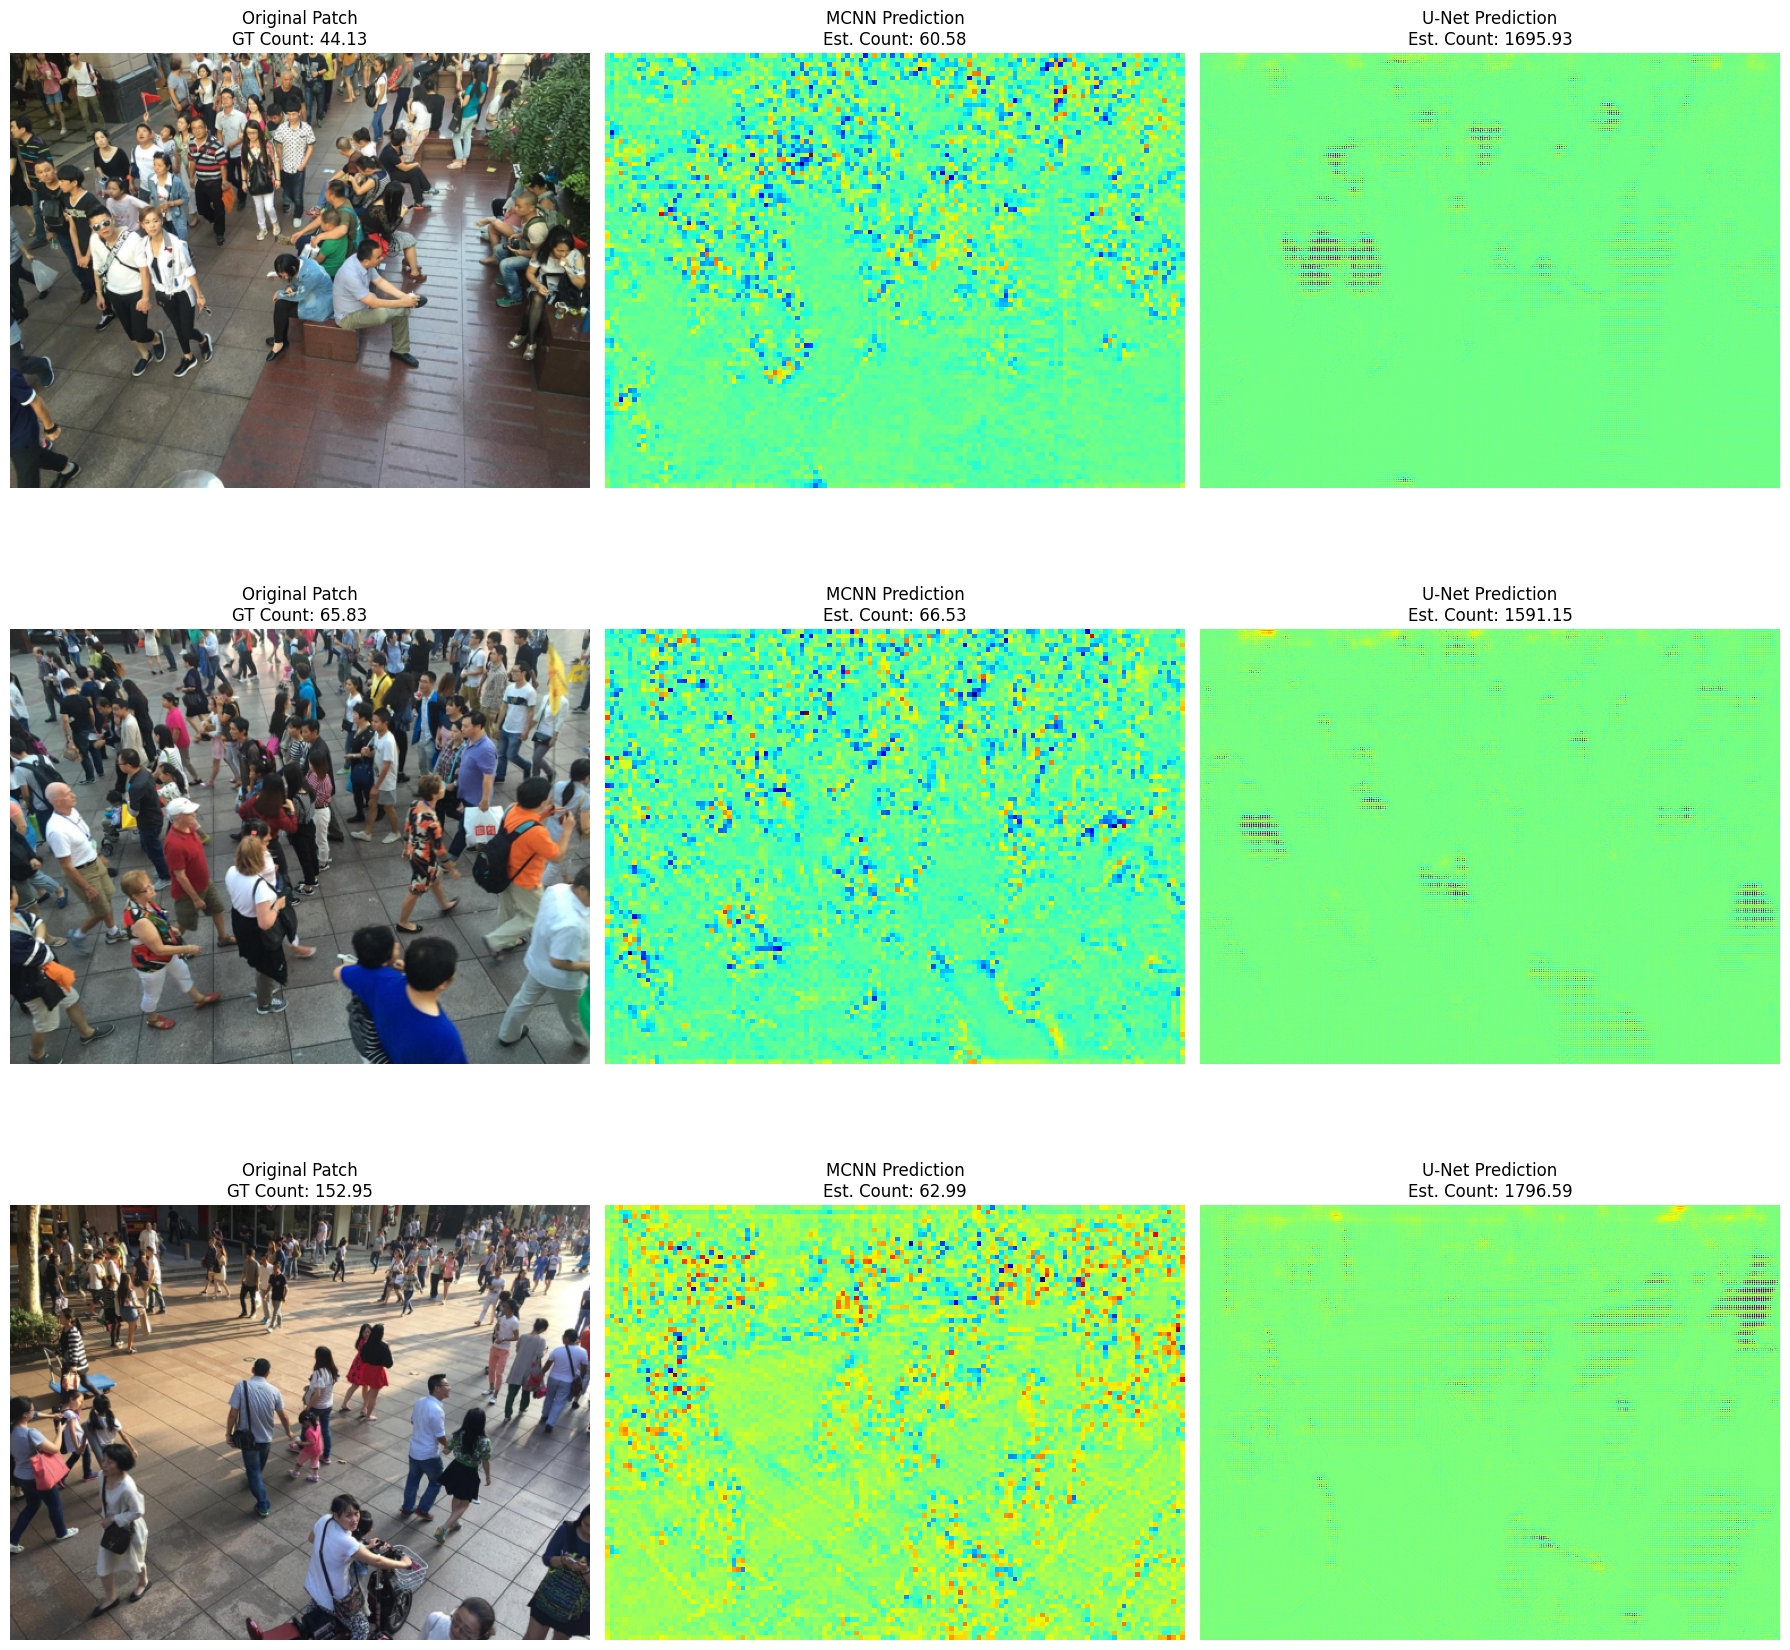

In [8]:
output_dir = "output_visualizations"
os.makedirs(output_dir, exist_ok=True)
print(f"Saving visualization images to the '{output_dir}/' directory.")

mcnn_model = MCNN().to(device)
mcnn_model.load_state_dict(torch.load('best_mcnn_model.pth'))
mcnn_model.eval()

unet_model = UNet(in_channels=3, out_channels=1).to(device)
unet_model.load_state_dict(torch.load('best_unet_model.pth'))
unet_model.eval()

dataset_to_visualize = test_dataset
num_images_to_show = 3
image_indices = random.sample(range(len(dataset_to_visualize)), num_images_to_show)

fig, axes = plt.subplots(num_images_to_show, 3, figsize=(18, 18))
if num_images_to_show == 1:
    axes = [axes]
for i, img_idx in enumerate(image_indices):
    image, gt_map = dataset_to_visualize[img_idx]
    true_count = gt_map.sum().item()
    image_tensor = image.unsqueeze(0).to(device)
    with torch.no_grad():
        pred_map_mcnn = mcnn_model(image_tensor)
        pred_count_mcnn = torch.relu(pred_map_mcnn).sum().item()
        pred_map_unet = unet_model(image_tensor)
        gt_map_downsampled = F.interpolate(gt_map.unsqueeze(0), scale_factor=1/DOWNSAMPLE_FACTOR, mode='area')
        pred_count_unet = pred_map_unet.sum().item()

    img_for_display = image.numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_for_display = std * img_for_display + mean
    img_for_display = np.clip(img_for_display, 0, 1)
    pred_map_display_mcnn = pred_map_mcnn.squeeze().cpu().numpy()
    pred_map_display_unet = pred_map_unet.squeeze().cpu().numpy()
    axes[i, 0].imshow(img_for_display)
    axes[i, 0].set_title(f'Original Patch\nGT Count: {true_count:.2f}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(pred_map_display_mcnn, cmap='jet')
    axes[i, 1].set_title(f'MCNN Prediction\nEst. Count: {pred_count_mcnn:.2f}')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(pred_map_display_unet, cmap='jet')
    axes[i, 2].set_title(f'U-Net Prediction\nEst. Count: {pred_count_unet:.2f}')
    axes[i, 2].axis('off')

fig.tight_layout()
plt.show()